# AEMO Data Ingestion and Exploration

This notebook demonstrates the use of the `aemo_data` module for fetching and analyzing Australian Energy Market Operator (AEMO) datasets.

## Data Sources

The AEMO data module uses **NEMOSIS** (https://github.com/UNSW-CEEM/NEMOSIS) to fetch **actual** AEMO market data, including:
- **Energy Prices**: Regional Reference Price (RRP) and total demand at 5-minute intervals
- **FCAS Prices**: Frequency Control Ancillary Services prices for maintaining grid stability (regional)
- **Generation Mix**: Power output by fuel type (solar, wind, coal, gas, etc.)
- **Unit Dispatch**: Unit-specific dispatch targets and FCAS enablement (NEW)

### NEMOSIS Integration

NEMOSIS automatically:
- Downloads data from AEMO's NEMWEB archives
- Caches data locally for faster subsequent access
- Handles data parsing and formatting

AEMO publishes market data through:
- **NEMWEB**: http://nemweb.com.au/ - Historical market data archive
- **MMS Data Model**: Detailed pricing and generation records

### Important Notes

- **First run**: May take 1-2 minutes to download data from AEMO
- **Cached runs**: Much faster as data is loaded from local cache
- **Internet required**: NEMOSIS needs connectivity to download from AEMO servers
- **Data availability**: Use dates from 2-3 months ago for best reliability (recent data may still be preliminary)
- **Data resolution**: 5-minute dispatch intervals (288 intervals per day)

In [ ]:
import sys
sys.path.append('src')

from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import polars as pl
import numpy as np

from aemo_data import (
    fetch_aemo_dispatch_price,
    fetch_aemo_fcas_price,
    fetch_aemo_generation_by_fuel,
    fetch_aemo_unit_dispatch,
    fetch_aemo_data_bundle,
    fetch_aemo_data_bundle_with_dispatch,
    get_available_battery_duids,
    get_available_battery_units,
    get_dispatch_active_battery_units,
    AEMO_REGIONS,
    FCAS_SERVICES,
)
from dispatch_utils import (
    list_known_batteries,
    show_dispatch_table,
    list_dispatch_candidates,
    scan_duid_availability,
    scan_duid_historical_availability,
)


In [ ]:
# Optional: point to a manually-downloaded AEMO generator info file (XLS/XLSX/CSV).
# This is used when NEMOSIS can't download static tables due to AEMO User-Agent blocking.
# You can either:
#  - set an env var: AEMO_GENERATORS_FILE=/path/to/file.xls(x)
#  - or set GENERATOR_INFO_PATH below.
import os
from pathlib import Path

_default_generators = Path('src/data/aemo/NEM Registration and Exemption List.xls')
GENERATOR_INFO_PATH = None
if _default_generators.exists():
    GENERATOR_INFO_PATH = str(_default_generators)

GENERATOR_INFO_PATH = os.getenv('AEMO_GENERATORS_FILE') or GENERATOR_INFO_PATH
print('Generator info file:', GENERATOR_INFO_PATH or '(not set; will try NEMOSIS/static cache)')

Generator info file: (not set; will try NEMOSIS/static cache)


In [ ]:
print("Available AEMO Regions:")
print(AEMO_REGIONS)
print("\nAvailable FCAS Services:")
print(FCAS_SERVICES)

Available AEMO Regions:
['NSW1', 'QLD1', 'SA1', 'TAS1', 'VIC1']

Available FCAS Services:
['RAISE6SEC', 'LOWER6SEC', 'RAISE60SEC', 'LOWER60SEC', 'RAISE5MIN', 'LOWER5MIN', 'RAISEREG', 'LOWERREG']


## Sample DUIDs for Testing

Here are some commonly used DUIDs across different regions and technologies:

### Battery Energy Storage Systems (BESS)
- **HPRG1** - Hornsdale Power Reserve (SA) - 150 MW / 194 MWh
- **LBBG1** - Lake Bonney Battery (SA) - 25 MW / 52 MWh
- **DALNTH01** - Dalrymple North BESS (SA) - 30 MW / 8 MWh
- **GANNBG1** - Gannawarra BESS (VIC) - 25 MW / 50 MWh
- **BALBG1** - Ballarat BESS (VIC) - 30 MW / 30 MWh

### Solar Farms
- **SUNSH1** - Sunraysia Solar Farm (VIC) - 100 MW
- **NYNGAN1** - Nyngan Solar Plant (NSW) - 102 MW
- **BROKENH1** - Broken Hill Solar Plant (NSW) - 53 MW
- **CLARESF1** - Clare Solar Farm (QLD) - 100 MW

### Wind Farms
- **SNOWTWN1** - Snowtown Wind Farm (SA) - 129 MW
- **NBHWF1** - North Brown Hill Wind Farm (SA) - 132 MW
- **MACARTH1** - Macarthur Wind Farm (VIC) - 420 MW
- **CAPTL_WF** - Capital Wind Farm (NSW) - 140 MW

### Gas Generators
- **PPCCGT** - Pelican Point CCGT (SA) - 478 MW
- **TORRB1** - Torrens Island B (SA) - 800 MW
- **VPGS1** - Valley Power Peaking Station (VIC) - 300 MW

### Hydro
- **TUMMER1** - Tumut 3 (NSW) - 1500 MW
- **MURRAY** - Murray (NSW) - 1500 MW
- **GUTHEGA** - Guthega (NSW) - 60 MW

**Note**: DUID availability varies by date. Use dates when the unit was operational.

## 1. Fetch Regional Market Data

Let's fetch 12 hours of actual AEMO data from June 2023. Using historical data ensures reliability as it's fully archived.

In [ ]:
# Define date range (using historical data for reliability)
# Use data from several months ago as it's fully archived and stable
start_date = datetime(2023, 6, 1, 0, 0, 0)
end_date = datetime(2023, 6, 1, 12, 0, 0)  # 12 hours of data
region = AEMO_REGIONS[-1]

print(f"Fetching ACTUAL AEMO data from {start_date} to {end_date}")
print(f"Region: {region}")
print("\nNote: First run will download data from AEMO (1-2 minutes)")
print("      Subsequent runs use cached data (much faster)")

Fetching ACTUAL AEMO data from 2023-06-01 00:00:00 to 2023-06-01 12:00:00
Region: VIC1

Note: First run will download data from AEMO (1-2 minutes)
      Subsequent runs use cached data (much faster)


### 1.1 Energy Prices

In [ ]:
# Fetch energy prices
prices = fetch_aemo_dispatch_price(start_date, end_date, region=region)

print("\nEnergy Price Data:")
print(prices.head())
print(f"\nTotal records: {len(prices)}")
print(f"\nPrice statistics ($/MWh):")
print(prices.select(["RRP", "TOTALDEMAND"]).describe())

Fetching dispatch price data for VIC1 from 2023-06-01 to 2023-06-01...
INFO: Compiling data for table DISPATCHPRICE
INFO: Downloading data for table DISPATCHPRICE, year 2023, month 05
INFO: Creating feather file for DISPATCHPRICE, 2023, 05
INFO: Downloading data for table DISPATCHPRICE, year 2023, month 06
INFO: Creating feather file for DISPATCHPRICE, 2023, 06
INFO: Returning DISPATCHPRICE.
INFO: Compiling data for table DISPATCHREGIONSUM
INFO: Downloading data for table DISPATCHREGIONSUM, year 2023, month 05
INFO: Creating feather file for DISPATCHREGIONSUM, 2023, 05
INFO: Downloading data for table DISPATCHREGIONSUM, year 2023, month 06
INFO: Creating feather file for DISPATCHREGIONSUM, 2023, 06
INFO: Returning DISPATCHREGIONSUM.
Fetched 144 price records

Energy Price Data:
shape: (5, 4)
┌─────────────────────┬──────────┬───────────┬─────────────┐
│ SETTLEMENTDATE      ┆ REGIONID ┆ RRP       ┆ TOTALDEMAND │
│ ---                 ┆ ---      ┆ ---       ┆ ---         │
│ datetime[ns]

### 1.2 FCAS Prices (Regional)

In [ ]:
# Fetch FCAS prices for regulation services
fcas_raise = fetch_aemo_fcas_price(start_date, end_date, region=region, service="RAISEREG")
fcas_lower = fetch_aemo_fcas_price(start_date, end_date, region=region, service="LOWERREG")

print("\nFCAS Raise Regulation Prices:")
print(fcas_raise.head())

print("\nFCAS Price Statistics ($/MW/h):")
print(fcas_raise.select(["PRICE"]).describe())

Fetching FCAS RAISEREG price data for VIC1 from 2023-06-01 to 2023-06-01...
INFO: Compiling data for table DISPATCHPRICE
INFO: Returning DISPATCHPRICE.
Fetched 144 FCAS price records
Fetching FCAS LOWERREG price data for VIC1 from 2023-06-01 to 2023-06-01...
INFO: Compiling data for table DISPATCHPRICE
INFO: Returning DISPATCHPRICE.
Fetched 144 FCAS price records

FCAS Raise Regulation Prices:
shape: (5, 4)
┌─────────────────────┬──────────┬──────────┬───────┐
│ SETTLEMENTDATE      ┆ REGIONID ┆ SERVICE  ┆ PRICE │
│ ---                 ┆ ---      ┆ ---      ┆ ---   │
│ datetime[ns]        ┆ str      ┆ str      ┆ f64   │
╞═════════════════════╪══════════╪══════════╪═══════╡
│ 2023-06-01 00:05:00 ┆ VIC1     ┆ RAISEREG ┆ 6.0   │
│ 2023-06-01 00:10:00 ┆ VIC1     ┆ RAISEREG ┆ 5.0   │
│ 2023-06-01 00:15:00 ┆ VIC1     ┆ RAISEREG ┆ 12.0  │
│ 2023-06-01 00:20:00 ┆ VIC1     ┆ RAISEREG ┆ 7.99  │
│ 2023-06-01 00:25:00 ┆ VIC1     ┆ RAISEREG ┆ 7.5   │
└─────────────────────┴──────────┴──────────┴────

### 1.3 Generation by Fuel Type

In [ ]:
# Fetch generation data
generation = fetch_aemo_generation_by_fuel(
    start_date, end_date,
    region=region,
    fuel_types=["solar", "wind"],
    generator_info_path=GENERATOR_INFO_PATH,
 )

print("\nGeneration Data:")
print(generation.head())
print(f"\nTotal records: {len(generation)}")

Fetching generation data for ['solar', 'wind'] in VIC1 from 2023-06-01 to 2023-06-01...
INFO: Retrieving static table Generators and Scheduled Loads
INFO: Compiling data for table DISPATCH_UNIT_SCADA
INFO: Returning DISPATCH_UNIT_SCADA.
Fetched 288 generation records

Generation Data:
shape: (5, 4)
┌─────────────────────┬──────────┬───────────┬─────────────┐
│ SETTLEMENTDATE      ┆ REGIONID ┆ FUEL_TYPE ┆ GENERATION  │
│ ---                 ┆ ---      ┆ ---       ┆ ---         │
│ datetime[ns]        ┆ str      ┆ str       ┆ f64         │
╞═════════════════════╪══════════╪═══════════╪═════════════╡
│ 2023-06-01 00:05:00 ┆ VIC1     ┆ solar     ┆ 0.0         │
│ 2023-06-01 00:05:00 ┆ VIC1     ┆ wind      ┆ 3058.987006 │
│ 2023-06-01 00:10:00 ┆ VIC1     ┆ solar     ┆ 0.0         │
│ 2023-06-01 00:10:00 ┆ VIC1     ┆ wind      ┆ 2945.25895  │
│ 2023-06-01 00:15:00 ┆ VIC1     ┆ solar     ┆ 0.0         │
└─────────────────────┴──────────┴───────────┴─────────────┘

Total records: 288


## 2. Fetch Unit-Specific Dispatch Data (NEW)

The new `fetch_aemo_unit_dispatch()` function fetches unit-specific dispatch targets and FCAS enablement from the DISPATCHLOAD table. This is essential for calculating actual FCAS revenue and understanding operational constraints.

### 2.1 Fetch Dispatch Data for a Specific Battery

In [ ]:
duid = "BALBG1"  # Hornsdale Power Reserve (HPRG1) - SA's big battery
# Fetch dispatch data for Hornsdale Power Reserve (HPRG1) - SA's big battery
unit_dispatch = fetch_aemo_unit_dispatch(
    start_date=datetime(2023, 6, 1, 0, 0, 0),
    end_date=datetime(2023, 6, 1, 6, 0, 0),  # 6 hours
    duid=duid,
    region=region,
    generator_info_path=GENERATOR_INFO_PATH,
)

print(f"\nUnit Dispatch Data for {duid}:")
print(unit_dispatch.head())
print(f"\nTotal dispatch records: {len(unit_dispatch)}")
print(f"\nColumns available: {unit_dispatch.columns}")

Fetching unit dispatch data for DUID BALBG1 in VIC1 from 2023-06-01 to 2023-06-01...
INFO: Compiling data for table DISPATCHLOAD
INFO: Returning DISPATCHLOAD.
DUID filter: 32976 records before filter, 72 after filtering for 'BALBG1'
Fetched 72 dispatch records for 1 unique units

Unit Dispatch Data for BALBG1:
shape: (5, 11)
┌────────────┬────────┬────────────┬───────────┬───┬───────────┬────────────┬───────────┬──────────┐
│ SETTLEMENT ┆ DUID   ┆ TOTALCLEAR ┆ RAISE6SEC ┆ … ┆ LOWER6SEC ┆ LOWER60SEC ┆ LOWER5MIN ┆ LOWERREG │
│ DATE       ┆ ---    ┆ ED         ┆ ---       ┆   ┆ ---       ┆ ---        ┆ ---       ┆ ---      │
│ ---        ┆ str    ┆ ---        ┆ f64       ┆   ┆ f64       ┆ f64        ┆ f64       ┆ f64      │
│ datetime[n ┆        ┆ f64        ┆           ┆   ┆           ┆            ┆           ┆          │
│ s]         ┆        ┆            ┆           ┆   ┆           ┆            ┆           ┆          │
╞════════════╪════════╪════════════╪═══════════╪═══╪═══════════╪═══

### 2.2 Analyze FCAS Enablement

In [ ]:
# Check which FCAS services the battery was enabled for
if len(unit_dispatch) > 0:
    detected_services = []
    for col in unit_dispatch.columns:
        col_upper = col.upper()
        matched = next((service for service in FCAS_SERVICES if col_upper.startswith(service)), None)
        if matched:
            detected_services.append((col, matched))
    if not detected_services:
        fallback = [col for col in unit_dispatch.columns if 'ACTUALAVAILABILITY' in col.upper()]
        for col in fallback:
            service_label = col.upper().replace('ACTUALAVAILABILITY', '')
            detected_services.append((col, service_label))

    print("\nFCAS Enablement Summary:")
    if not detected_services:
        print("  No FCAS enablement columns detected in the dispatch data.")
    else:
        for col, service_name in detected_services:
            enablement_series = unit_dispatch[col]
            max_enabled = enablement_series.max()
            avg_enabled = enablement_series.mean()
            print(f"{service_name:20s}: Max={max_enabled:6.1f} MW, Avg={avg_enabled:6.1f} MW")


FCAS Enablement Summary:
RAISE6SEC           : Max=  30.0 MW, Avg=  29.5 MW
RAISE60SEC          : Max=  30.0 MW, Avg=  29.5 MW
RAISE5MIN           : Max=  30.0 MW, Avg=  29.5 MW
RAISEREG            : Max=  30.0 MW, Avg=   0.5 MW
LOWER6SEC           : Max=   0.0 MW, Avg=   0.0 MW
LOWER60SEC          : Max=   0.0 MW, Avg=   0.0 MW
LOWER5MIN           : Max=   0.0 MW, Avg=   0.0 MW
LOWERREG            : Max=   0.0 MW, Avg=   0.0 MW


### 2.3 Calculate FCAS Revenue

Revenue = Enablement (MW) × Price ($/MW/h) × interval duration (hours)

In [ ]:
# Fetch FCAS prices for SA1
fcas_prices_sa = fetch_aemo_fcas_price(
    datetime(2023, 6, 1, 0, 0, 0),
    datetime(2023, 6, 1, 6, 0, 0),
    region=region,
    service="RAISEREG"
)

# Join enablement with prices (simplified example)
if len(unit_dispatch) > 0 and len(fcas_prices_sa) > 0:
    dispatch_pd = unit_dispatch.to_pandas()
    prices_pd = fcas_prices_sa.to_pandas()
    
    merged = dispatch_pd.merge(prices_pd, on='SETTLEMENTDATE', how='inner')
    
    availability_col = next(
        (col for col in merged.columns if col.upper() in {'RAISEREG', 'RAISEREGACTUALAVAILABILITY'}),
        None,
    )
    if len(merged) > 0 and availability_col:
        merged['RAISEREG_REVENUE'] = merged[availability_col] * merged['PRICE'] * (5/60)
        
        total_revenue = merged['RAISEREG_REVENUE'].sum()
        print(f"\nEstimated FCAS RAISEREG Revenue for 6 hours: ${total_revenue:,.2f}")
        print(f"Average revenue per interval: ${merged['RAISEREG_REVENUE'].mean():.2f}")

Fetching FCAS RAISEREG price data for VIC1 from 2023-06-01 to 2023-06-01...
INFO: Compiling data for table DISPATCHPRICE
INFO: Returning DISPATCHPRICE.
Fetched 72 FCAS price records

Estimated FCAS RAISEREG Revenue for 6 hours: $23.62
Average revenue per interval: $0.33


## 3. Comprehensive Data Bundle with Dispatch

Use the new `fetch_aemo_data_bundle_with_dispatch()` wrapper to fetch all market data in one call.

In [ ]:
# Fetch comprehensive data for a battery unit
data_bundle = fetch_aemo_data_bundle_with_dispatch(
    start_date=datetime(2023, 6, 1, 0, 0, 0),
    end_date=datetime(2023, 6, 1, 3, 0, 0),  # 3 hours
    region=region,
    duid=duid,
    fcas_services=["RAISEREG", "LOWERREG"],
    fuel_types=["solar", "wind"],
    generator_info_path=GENERATOR_INFO_PATH,
 )

print("\nData Bundle Contents:")
print(f"Energy prices: {len(data_bundle['prices'])} records")
print(f"FCAS prices: {len(data_bundle['fcas'])} records")
print(f"Generation: {len(data_bundle['generation'])} records")
print(f"Unit dispatch: {len(data_bundle['unit_dispatch'])} records")

print("\nUnit Dispatch Sample:")
print(data_bundle['unit_dispatch'].head())

Fetching comprehensive AEMO data bundle for VIC1 for DUID BALBG1 from 2023-06-01 to 2023-06-01...
Fetching dispatch price data for VIC1 from 2023-06-01 to 2023-06-01...
INFO: Compiling data for table DISPATCHPRICE
INFO: Returning DISPATCHPRICE.
INFO: Compiling data for table DISPATCHREGIONSUM
INFO: Returning DISPATCHREGIONSUM.
Fetched 36 price records
Fetching FCAS RAISEREG price data for VIC1 from 2023-06-01 to 2023-06-01...
INFO: Compiling data for table DISPATCHPRICE
INFO: Returning DISPATCHPRICE.
Fetched 36 FCAS price records
Fetching FCAS LOWERREG price data for VIC1 from 2023-06-01 to 2023-06-01...
INFO: Compiling data for table DISPATCHPRICE
INFO: Returning DISPATCHPRICE.
Fetched 36 FCAS price records
Fetching generation data for ['solar', 'wind'] in VIC1 from 2023-06-01 to 2023-06-01...
INFO: Retrieving static table Generators and Scheduled Loads
INFO: Compiling data for table DISPATCH_UNIT_SCADA
INFO: Returning DISPATCH_UNIT_SCADA.
Fetched 72 generation records
Fetching unit d

## 4. Explore Different DUIDs

Let's try fetching data for different unit types to see what's available.

In [ ]:
# Test different DUIDs
test_duids = [
    ("HPRG1", "SA1", "Battery - Hornsdale"),
    ("LBBG1", "SA1", "Battery - Lake Bonney"),
    ("SUNSH1", "VIC1", "Solar - Sunraysia"),
    ("SNOWTWN1", "SA1", "Wind - Snowtown"),
]

print("Testing dispatch data availability for different units:\n")

for duid, region, description in test_duids:
    try:
        dispatch = fetch_aemo_unit_dispatch(
            start_date=datetime(2023, 6, 1, 0, 0, 0),
            end_date=datetime(2023, 6, 1, 1, 0, 0),  # 1 hour
            duid=duid,
            region=region,
            generator_info_path=GENERATOR_INFO_PATH,
        )
        print(f"✓ {duid:12s} ({description:25s}): {len(dispatch)} records")
    except Exception as e:
        print(f"✗ {duid:12s} ({description:25s}): Error - {str(e)[:50]}")

Testing dispatch data availability for different units:

Fetching unit dispatch data for DUID HPRG1 in SA1 from 2023-06-01 to 2023-06-01...
INFO: Compiling data for table DISPATCHLOAD
INFO: Returning DISPATCHLOAD.
DUID filter: 5496 records before filter, 12 after filtering for 'HPRG1'
Fetched 12 dispatch records for 1 unique units
✓ HPRG1        (Battery - Hornsdale      ): 12 records
Fetching unit dispatch data for DUID LBBG1 in SA1 from 2023-06-01 to 2023-06-01...
INFO: Compiling data for table DISPATCHLOAD
INFO: Returning DISPATCHLOAD.
DUID filter: 5496 records before filter, 12 after filtering for 'LBBG1'
Fetched 12 dispatch records for 1 unique units
✓ LBBG1        (Battery - Lake Bonney    ): 12 records
Fetching unit dispatch data for DUID SUNSH1 in VIC1 from 2023-06-01 to 2023-06-01...
INFO: Compiling data for table DISPATCHLOAD
INFO: Returning DISPATCHLOAD.
DUID filter: 5496 records before filter, 0 after filtering for 'SUNSH1'
Hint: Check if DUID 'SUNSH1' exists in DISPATCHLOA

## 5. Visualizations

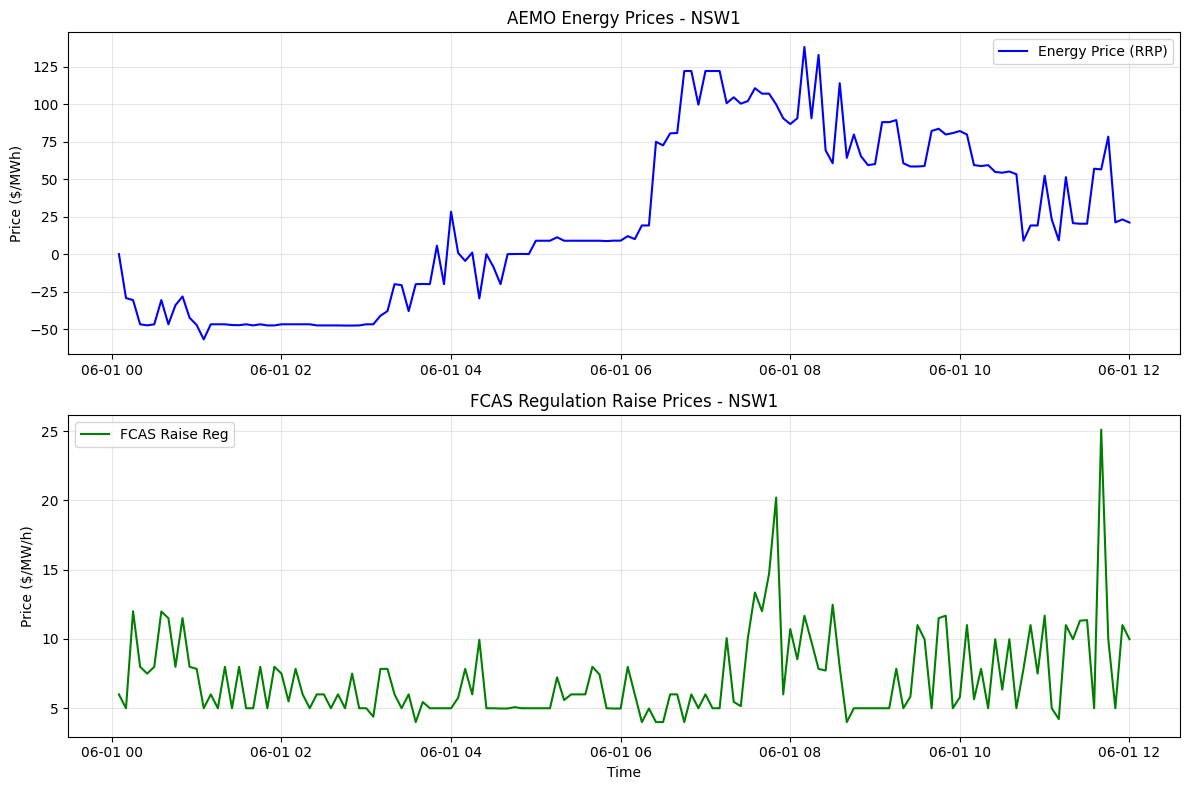

In [ ]:
# Plot energy and FCAS prices
if len(prices) > 0 and len(fcas_raise) > 0:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
    
    # Energy prices
    energy_col = next((col for col in ('PRICE', 'RRP') if col in prices.columns), None)
    if energy_col:
        energy_times = prices['SETTLEMENTDATE'].to_list()
        energy_values = prices[energy_col].to_list()
        ax1.plot(energy_times, energy_values, label=f'Energy Price ({energy_col})', color='blue')
    else:
        ax1.text(0.5, 0.5, 'No energy price column available', ha='center')
    ax1.set_ylabel('Price ($/MWh)')
    ax1.set_title('AEMO Energy Prices - NSW1')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # FCAS prices
    fcas_col = 'PRICE' if 'PRICE' in fcas_raise.columns else None
    if fcas_col:
        fcas_times = fcas_raise['SETTLEMENTDATE'].to_list()
        fcas_values = fcas_raise[fcas_col].to_list()
        ax2.plot(fcas_times, fcas_values, label='FCAS Raise Reg', color='green')
    else:
        ax2.text(0.5, 0.5, 'No FCAS price column available', ha='center')
    ax2.set_ylabel('Price ($/MW/h)')
    ax2.set_xlabel('Time')
    ax2.set_title('FCAS Regulation Raise Prices - NSW1')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

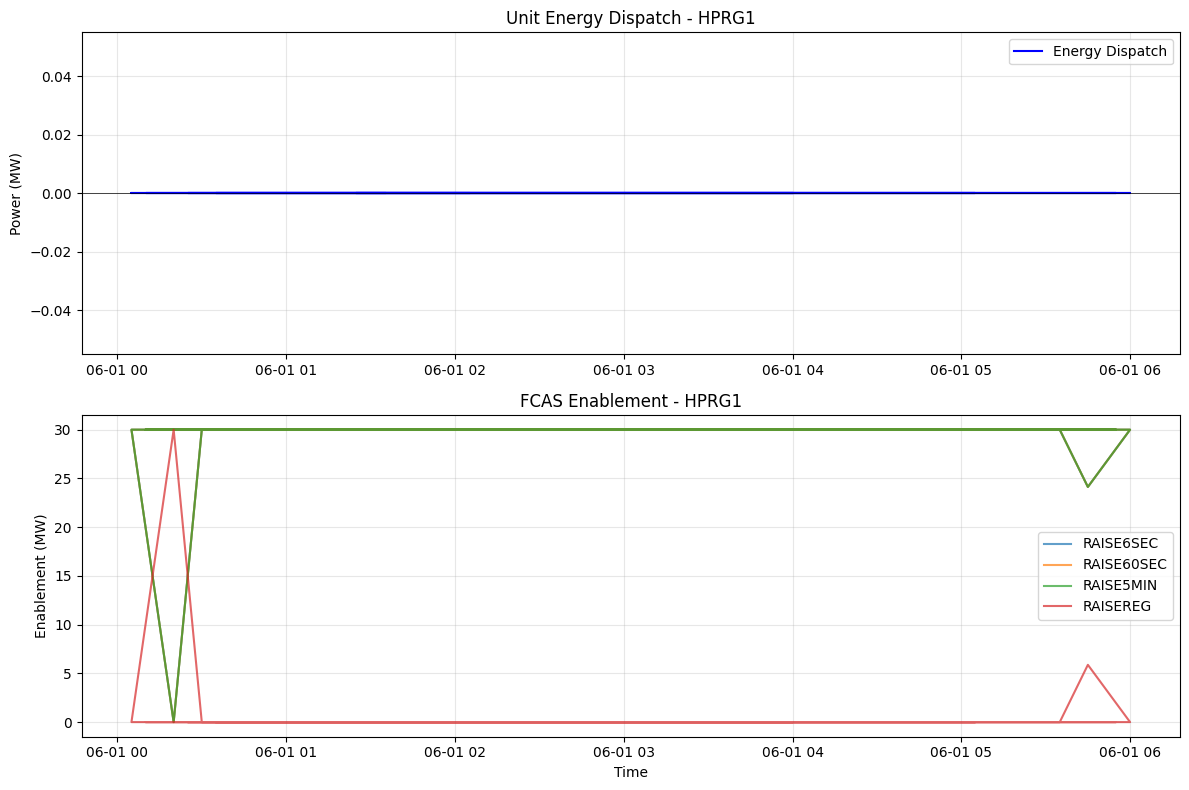

In [ ]:
# Plot unit dispatch and FCAS enablement
if len(unit_dispatch) > 0:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
    
    dispatch_times = unit_dispatch['SETTLEMENTDATE'].to_list()
    
    # Energy dispatch
    energy_plotted = False
    if 'TOTALCLEARED' in unit_dispatch.columns:
        total_cleared = unit_dispatch['TOTALCLEARED'].to_list()
        ax1.plot(dispatch_times, total_cleared, label='Energy Dispatch', color='blue')
        ax1.set_ylabel('Power (MW)')
        ax1.set_title('Unit Energy Dispatch - HPRG1')
        energy_plotted = True
    if energy_plotted:
        ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
    
    # FCAS enablement
    fcas_cols = [col for col in unit_dispatch.columns if 'RAISE' in col.upper() or 'LOWER' in col.upper()]
    plotted_services = 0
    for col in fcas_cols[:4]:  # Plot first 4 FCAS services
        service_name = col.replace('ACTUALAVAILABILITY', '')
        ax2.plot(dispatch_times, unit_dispatch[col].to_list(), label=service_name, alpha=0.7)
        plotted_services += 1
    
    if plotted_services:
        ax2.legend()
    else:
        ax2.text(0.5, 0.5, 'No FCAS enablement columns available', ha='center')
    ax2.set_ylabel('Enablement (MW)')
    ax2.set_xlabel('Time')
    ax2.set_title('FCAS Enablement - HPRG1')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

---
## 5. DUID Availability Explorer

This section shows which battery DUIDs are registered in each NEM region and
which were **actively dispatched** during a given date window.  Use this to
discover good DUIDs for dispatch replay in `test_aemo_simrun.ipynb`.

### 5.1 List all battery DUIDs by region (static table)

In [ ]:
# List all battery DUIDs across all NEM regions from the AEMO static table.
# This uses the bundled NEM Registration & Exemption List – no network required.
EXPLORE_CACHE_DIR = "data/aemo"

for region in AEMO_REGIONS:
    units = get_available_battery_units(cache_dir=EXPLORE_CACHE_DIR, region=region)
    if units.height == 0:
        print(f"{region}: no batteries found")
        continue
    print(f"\n{'='*60}")
    show_dispatch_table(
        units,
        ["DUID", "Region", "DispatchType", "TechnologyType", "StorageCapacityMWh", "RegisteredCapacityMW"],
        label=f"Batteries in {region} ({units.height} units)",
    )


INFO: Retrieving static table Generators and Scheduled Loads


Batteries in NSW1 (14 units)
shape: (14, 6)
┌──────────┬────────┬───────────────┬────────────────┬──────────────────────┬──────────────────────┐
│ DUID     ┆ Region ┆ DispatchType  ┆ TechnologyType ┆ StorageCapacityMWh   ┆ RegisteredCapacityMW │
│ ---      ┆ ---    ┆ ---           ┆ ---            ┆ ---                  ┆ ---                  │
│ str      ┆ str    ┆ str           ┆ str            ┆ f64                  ┆ f64                  │
╞══════════╪════════╪═══════════════╪════════════════╪══════════════════════╪══════════════════════╡
│ BHB1     ┆ NSW1   ┆ Bidirectional ┆ Battery and    ┆ 50.0                 ┆ 66.0                 │
│          ┆        ┆ Unit          ┆ Inverter       ┆                      ┆                      │
│ CAPBES1  ┆ NSW1   ┆ Bidirectional ┆ Battery and    ┆ 200.0                ┆ 125.0                │
│          ┆        ┆ Unit          ┆ Inverter       ┆                      ┆        

### 5.2 Find dispatch-active DUIDs for a date window

Choose a region and date range to see which batteries were **actually dispatched**
during that period, sorted by activity (`NonZeroIntervalCount`).

> **Tip**: Batteries with higher `NonZeroIntervalCount` and `MaxEnergyMW` are
> more useful for dispatch replay.  Batteries with `NonZeroIntervalCount=0` were
> registered but not dispatched during this window — they will produce all-zero
> actions in replay mode.

> **Why do older dates (before 2024) show zero activity for most DUIDs?**
>
> This is **expected behaviour** for the following two reasons:
>
> 1. **Newly commissioned batteries** — Most batteries in the current static table
>    were built and commissioned between 2022 and 2025.  They simply did not exist
>    before their commissioning date, so earlier queries will return no data.
>
> 2. **DUID re-registration (old gen/load pairs → Bidirectional Units)** — Before
>    2021, AEMO registered batteries as *two* separate DUIDs: a *Generating Unit*
>    (discharge, e.g. `HPRG1`) and a *Load* (charge, e.g. `HPRL1`).  From 2021
>    onwards, AEMO introduced *Bidirectional Unit* DUIDs (e.g. `HPR1`) where a
>    single DUID handles both charge and discharge.  When a battery transitions,
>    the old DUIDs are retired.  **The new Bidirectional DUID only appears in
>    DISPATCHLOAD from the transition date**, so scanning `HPR1` for 2022 will
>    find nothing — even though Hornsdale Power Reserve has been operational since
>    2017 (under `HPRG1` / `HPRL1`).
>
> The `FirstDispatchInterval` column in the output below shows when each battery
> **first appeared in DISPATCHLOAD under its current DUID** — not the battery's
> original commissioning date.  Use section 5.5 to scan a wider historical range
> and pinpoint the earliest available date.

In [ ]:
# --- Configure the date window to explore --------------------------------
EXPLORE_REGION = "SA1"           # Change to any NEM region: NSW1, QLD1, SA1, TAS1, VIC1
EXPLORE_START  = datetime(2025, 1, 1)
EXPLORE_END    = datetime(2025, 1, 7)

In [ ]:
battery_units_explore, active_units_explore = list_dispatch_candidates(
    region=EXPLORE_REGION,
    start_date=EXPLORE_START,
    end_date=EXPLORE_END,
    cache_dir=EXPLORE_CACHE_DIR,
)

INFO: Retrieving static table Generators and Scheduled Loads
Available battery DUIDs in SA1: 15

Static-table battery units
shape: (15, 7)
┌──────────┬────────┬────────────────┬────────────────┬──────────┬────────────────┬────────────────┐
│ DUID     ┆ Region ┆ DispatchType   ┆ TechnologyType ┆ FuelType ┆ StorageCapacit ┆ RegisteredCapa │
│ ---      ┆ ---    ┆ ---            ┆ ---            ┆ ---      ┆ yMWh           ┆ cityMW         │
│ str      ┆ str    ┆ str            ┆ str            ┆ str      ┆ ---            ┆ ---            │
│          ┆        ┆                ┆                ┆          ┆ f64            ┆ f64            │
╞══════════╪════════╪════════════════╪════════════════╪══════════╪════════════════╪════════════════╡
│ BLYTHB1  ┆ SA1    ┆ Bidirectional  ┆ Battery and    ┆ Grid     ┆ 400.0          ┆ 281.0          │
│          ┆        ┆ Unit           ┆ Inverter       ┆          ┆                ┆                │
│ BUNGAMB1 ┆ SA1    ┆ Bidirectional  ┆ Battery and   

### 5.3 Cross-region availability scan

Use `scan_duid_availability` to get a single table spanning **all regions**
and all battery DUIDs, with dispatch-activity statistics for a chosen date window.
The `InDispatchLoad` column is `True` when the unit appeared in DISPATCHLOAD.

If most DUIDs show `InDispatchLoad=False` for your date window, try:
- Moving the window to 2025 (where most current DUIDs are active)
- Using section 5.5 to find the earliest date each DUID has data

In [ ]:
# Scan all NEM regions for battery DUID activity in the chosen window.
# This fetches DISPATCHLOAD data – may take a few minutes on first run.
availability_summary = scan_duid_availability(
    regions=AEMO_REGIONS,
    start_date=EXPLORE_START,
    end_date=EXPLORE_END,
    cache_dir=EXPLORE_CACHE_DIR,
)

print(f"Total battery DUIDs scanned: {availability_summary.height}")
print(f"In DISPATCHLOAD: {availability_summary.filter(pl.col('InDispatchLoad')).height}")
print(f"Not in DISPATCHLOAD: {availability_summary.filter(~pl.col('InDispatchLoad')).height}")
print()
show_dispatch_table(
    availability_summary,
    [
        "DUID", "Region", "DispatchType",
        "StorageCapacityMWh", "RegisteredCapacityMW",
        "InDispatchLoad", "NonZeroIntervalCount",
        "MaxEnergyMW", "FirstDispatchInterval", "LastDispatchInterval",
        "PairedGenDUID", "PairedLoadDUID",
    ],
    label=f"Battery DUID availability scan: {EXPLORE_START.date()} → {EXPLORE_END.date()}",
    limit=60,
)


INFO: Retrieving static table Generators and Scheduled Loads
INFO: Retrieving static table Generators and Scheduled Loads
INFO: Retrieving static table Generators and Scheduled Loads
INFO: Retrieving static table Generators and Scheduled Loads
INFO: Retrieving static table Generators and Scheduled Loads
INFO: Retrieving static table Generators and Scheduled Loads
Fetching unit dispatch data in NSW1 from 2025-01-01 to 2025-01-07...
INFO: Compiling data for table DISPATCHLOAD
INFO: Returning DISPATCHLOAD.
INFO: Retrieving static table Generators and Scheduled Loads
Region filter: 851904 records before filter, 167616 after filtering for region 'NSW1'
Fetched 167616 dispatch records for 97 unique units
INFO: Retrieving static table Generators and Scheduled Loads
Fetching unit dispatch data in QLD1 from 2025-01-01 to 2025-01-07...
INFO: Compiling data for table DISPATCHLOAD
INFO: Returning DISPATCHLOAD.
INFO: Retrieving static table Generators and Scheduled Loads
Region filter: 851904 recor

### 5.4 Visualise dispatch activity

Plot a bar chart showing ``NonZeroIntervalCount`` for each battery DUID that
appeared in DISPATCHLOAD.  This gives a quick visual overview of which batteries
were the most active.

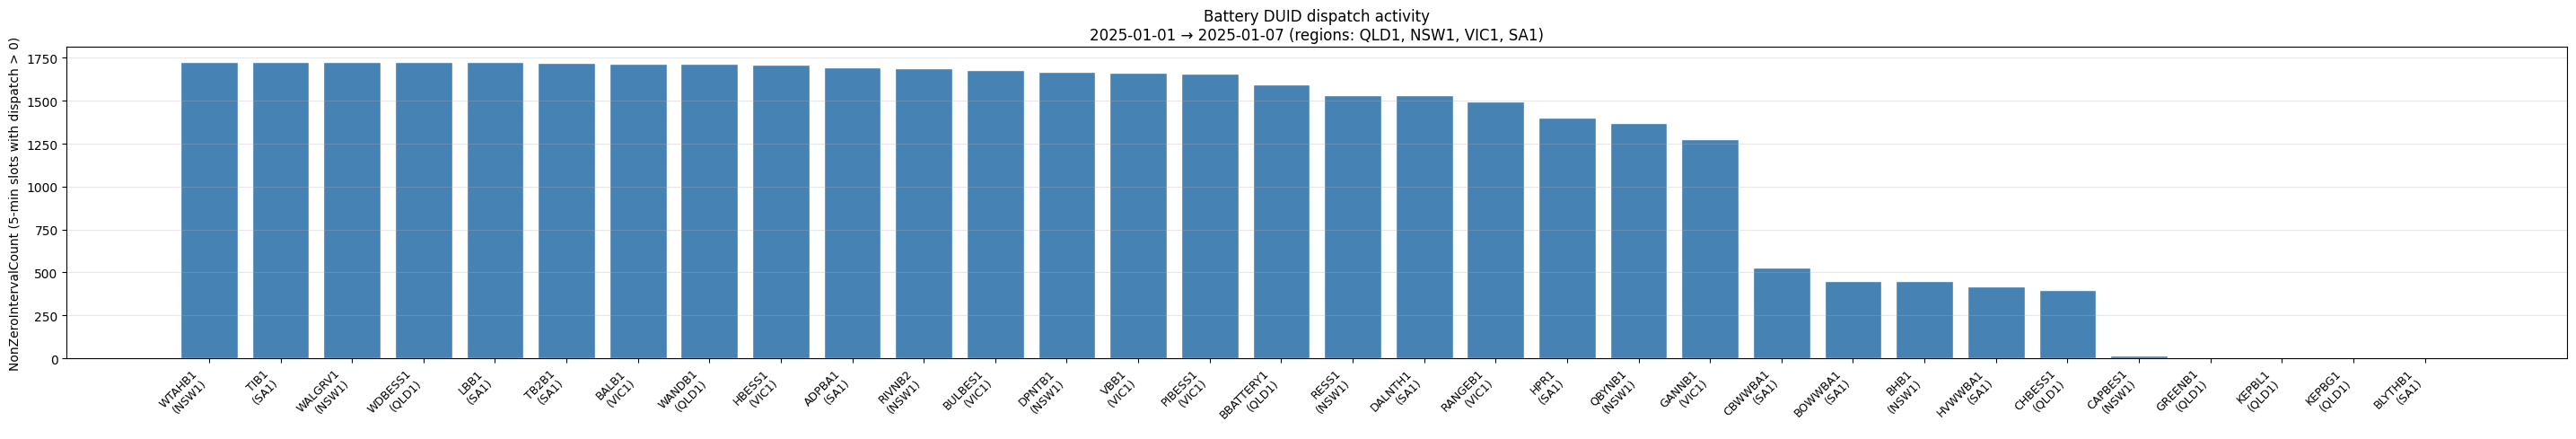


Most active DUID: WTAHB1 in NSW1 (1728 non-zero intervals)


In [ ]:
active_scan = availability_summary.filter(pl.col("InDispatchLoad"))
if active_scan.height == 0:
    print("[INFO] No batteries were dispatched in this window.")
else:
    # Sort by activity for a cleaner plot
    active_scan = active_scan.sort("NonZeroIntervalCount", descending=True)
    duids = active_scan["DUID"].to_list()
    regions = active_scan["Region"].to_list() if "Region" in active_scan.columns else [""] * len(duids)
    nonzero_counts = active_scan["NonZeroIntervalCount"].to_list() if "NonZeroIntervalCount" in active_scan.columns else [0] * len(duids)
    labels = [f"{d}\n({r})" for d, r in zip(duids, regions)]

    fig, ax = plt.subplots(figsize=(max(10, len(duids) * 0.9), 5))
    bars = ax.bar(range(len(labels)), nonzero_counts, color="steelblue", edgecolor="white")
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("NonZeroIntervalCount (5-min slots with dispatch > 0)")
    ax.set_title(
        f"Battery DUID dispatch activity\n{EXPLORE_START.date()} → {EXPLORE_END.date()} "
        f"(regions: {', '.join(set(regions))})"
    )
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(f"\nMost active DUID: {duids[0]} in {regions[0]} ({nonzero_counts[0]} non-zero intervals)")


### 5.5 Find when each battery was first dispatched (historical scan)

Use `scan_duid_historical_availability` to scan DISPATCHLOAD month-by-month from
a given start year and find the **earliest date each DUID appears in the data**.

This answers the question *"when was this battery first operational under its
current DUID?"* and explains why queries for dates before that point return
empty results.

> ⚠️ **This scan fetches data month-by-month from NEMOSIS (internet required)
> and may take several minutes for many DUIDs.**  Start with a small region
> or a short `search_start` to test before running the full scan.
> Results are cached by NEMOSIS, so subsequent runs are faster.

In [ ]:
from dispatch_utils import scan_duid_historical_availability

# --- Configure the historical scan ------------------------------------
# search_start: how far back to look. Batteries built before 2019 are rare
# in the NEM; set to datetime(2017, 1, 1) to catch early batteries.
HISTORY_SEARCH_START = datetime(2022, 1, 1)

# Scan only SA1 to keep the example fast; remove region filter to scan all.
history_df = scan_duid_historical_availability(
    regions=[EXPLORE_REGION],          # set to None for all regions
    search_start=HISTORY_SEARCH_START,
    cache_dir=EXPLORE_CACHE_DIR,
    verbose=True,
)

print()
print("Historical DUID first-dispatch dates:")
print(history_df)


#### Interpreting the results

| `FirstDispatchInHistory` | Meaning |
|--------------------------|---------|
| Close to `search_start` | Battery was already active before the search window — extend `search_start` backwards to find the true first date |
| Date in 2022–2025 | Likely reflects the re-registration date (old gen/load pair → Bidirectional Unit), not the battery commissioning date |
| `null` | DUID not found in the search range at all; battery might have been commissioned after `search_end`, or uses an older DUID |

For batteries with a `FirstDispatchInHistory` in 2022–2024, check if there is an
older DUID under the same station name (use section 5.1 to see `Station Name` or
look up the AEMO *NEM Registration and Exemption List* directly).  For example:

| Current Bidirectional DUID | Older Gen DUID | Older Load DUID | Re-registered ≈ |
|---------------------------|---------------|-----------------|-----------------|
| `HPR1` (Hornsdale SA1) | `HPRG1` | `HPRL1` | 2022 |
| `LBB1` (Lake Bonney SA1) | `LBBG1` | `LBBL1` | 2022 |
| `BALB1` (Ballarat VIC1) | `BALBG1` | — | 2023 |
| `GANNB1` (Gannawarra VIC1) | `GANNBG1` | `GANNBL1` | 2023 |
| `DALNTH1` (Dalrymple North SA1) | `DALNTH01` | — | 2023 |

To fetch historical data for an older DUID, call `fetch_aemo_unit_dispatch` directly:

```python
from aemo_data import fetch_aemo_unit_dispatch

# Fetch Hornsdale historical data using the OLD gen-direction DUID
old_dispatch = fetch_aemo_unit_dispatch(
    start_date=datetime(2022, 1, 1),
    end_date=datetime(2022, 1, 7),
    duid="HPRG1",
    cache_dir="data/aemo",
)
print(old_dispatch.head())
```

## Summary

This notebook demonstrated:

1. **Regional Market Data**: Fetching energy prices, FCAS prices, and generation mix
2. **Unit-Specific Dispatch**: NEW function to fetch dispatch targets and FCAS enablement for individual units
3. **FCAS Revenue Calculation**: How to join enablement with prices to calculate actual revenue
4. **Comprehensive Wrapper**: Using `fetch_aemo_data_bundle_with_dispatch()` for all data in one call
5. **DUID Availability Explorer**: Listing all battery DUIDs per region, finding which were dispatch-active for a chosen date window, scanning all regions via ``scan_duid_availability()``, and visualising activity
6. **Different Unit Types**: Testing various DUIDs (batteries, solar, wind, etc.)

### Key Takeaways

- Regional FCAS prices tell you what the market is paying
- Unit-specific enablement tells you what capacity was actually dispatched
- Revenue = Enablement (MW) × Price ($/MW/h) × interval duration
- Different unit types have different participation patterns in FCAS markets

### Next Steps

- Use this data to train RL agents for battery trading optimization
- Analyze correlations between renewable generation and FCAS prices
- Build reward functions that incorporate both energy arbitrage and FCAS revenue

## 6. Smoke Test: Polars-Based AEMO Trading Env

This section runs an end-to-end smoke test of the Polars-based preprocessing + `AEMOBatteryTradingEnv` using the `data_bundle` fetched above.

In [ ]:
from AEMOBatteryEnv import AEMODataPreprocessor, AEMOBatteryTradingEnv

# Reuse the bundle fetched above (data_bundle).
# If you skipped section 3, run it first so `data_bundle` exists.
pre = AEMODataPreprocessor(step_duration_hours=0.5)
processed = pre.preprocess_aemo_data(
    prices=data_bundle["prices"],
    fcas=data_bundle["fcas"],
    generation=data_bundle["generation"],
)

print("processed type:", type(processed))
print("processed shape:", processed.shape)
print("processed columns (first 20):", processed.columns[:20])

env = AEMOBatteryTradingEnv(
    aemo_data=processed,
    battery_capacity=10.0,
    max_battery_flow=5.0,
    init_battery_level=5.0,
    max_step=48,
    step_duration=0.5,
    action_mode="multi_market",
)

obs, info = env.reset(seed=0)
print("obs shape:", obs.shape)
print("info:", info)

for t in range(10):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    if t < 3 or terminated or truncated:
        print(f"t={t:02d} reward={reward: .4f} soc={info.get('battery_soc', None)}")
    if terminated or truncated:
        print("Episode ended.")
        break